# 1) Mount drive

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2) Import libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import manhattan_distances, euclidean_distances

# 3) Read dataset

In [14]:
df = pd.read_excel('/content/drive/MyDrive/ML/computational data mining/تمرین دهم/dataset/distances.xlsx')
df.head()

,Unnamed: 0,Ahvaz,Arak,Ardabil,Bandar Abbas,Birjand,Bojnord,Bushehr,Gorgan,Hamadan,...,Semnan,Shahr-e Kord,Shiraz,Tabriz,Tehran,Urmia,Yasuj,Yazd,Zahedan,Zanjan
0,Ahvaz,0,507,1202,1126,1352,1466,446,1159,557,...,920,464,520,1150,780,1050,416,805,1581,862
1,Arak,507,0,732,1269,1152,963,946,655,189,...,417,285,754,748,276,716,558,616,1467,460
2,Ardabil,1202,732,0,1813,1592,1060,1476,752,563,...,792,980,1357,217,573,357,1191,1160,2011,262
3,Bandar Abbas,1126,1269,1813,0,1043,1487,741,1659,1419,...,1407,967,579,1808,1280,1949,751,659,719,1520
4,Birjand,1352,1152,1592,1043,0,762,1343,934,1303,...,914,955,1060,1747,1136,1888,1002,630,450,1459


In [15]:
df.shape

(31, 32)

In [16]:
df.info

<bound method DataFrame.info of       Unnamed: 0  Ahvaz  Arak  Ardabil  Bandar Abbas  Birjand  Bojnord  \
0          Ahvaz      0   507     1202          1126     1352     1466   
1           Arak    507     0      732          1269     1152      963   
2        Ardabil   1202   732        0          1813     1592     1060   
3   Bandar Abbas   1126  1269     1813             0     1043     1487   
4        Birjand   1352  1152     1592          1043        0      762   
5        Bojnord   1466   963     1060          1487      762        0   
6        Bushehr    446   946     1476           741     1343     1716   
7         Gorgan   1159   655      752          1659      934      305   
8        Hamadan    557   189      563          1419     1303     1006   
9           Ilam    434   465      916          1598     1484     1359   
10       Isfahan    510   327      881           969      855     1119   
11         Karaj    787   283      529          1300     1178      730   
12        Kerman   1087   974     1518           488      561     1003   
13    Kermanshah    518   293      744          1467     1412     1187   
14   Khorramabad    330   177      788          1287     1232     1134   
15       Mashhad   1603  1099     1318          1400      504      258   
16        Qazvin    793   313      421          1392     1282      834   
17           Qom    636   133      647          1144     1028      827   
18         Rasht    954   484      255          1570     1336      800   
19      Sanandaj    642   360      547          1588     1471     1175   
20          Sari   1025   521      618          1525      978      437   
21        Semnan    920   417      792          1407      914      536   
22  Shahr-e Kord    464   285      980           967      955     1221   
23        Shiraz    520   754     1357           579     1060     1593   
24        Tabriz   1150   748      217          1808     1747     1299   
25        Tehran    780   276      573          1280     1136      687   
26         Urmia   1050   716      357          1949     1888     1440   
27         Yasuj    416   558     1191           751     1002     1431   
28          Yazd    805   616     1160           659      630      983   
29       Zahedan   1581  1467     2011           719      450     1206   
30        Zanjan    862   460      262          1520     1459     1011   

    Bushehr  Gorgan  Hamadan  ...  Semnan  Shahr-e Kord  Shiraz  Tabriz  \
0       446    1159      557  ...     920           464     520    1150   
1       946     655      189  ...     417           285     754     748   
2      1476     752      563  ...     792           980    1357     217   
3       741    1659     1419  ...    1407           967     579    1808   
4      1343     934     1303  ...     914           955    1060    1747   
5      1716     305     1006  ...     536          1221    1593    1299   
6         0    1414      999  ...    1162           553     287    1497   
7      1414       0      701  ...     339           915    1288     994   
8       999     701        0  ...     516           459     948     597   
9       876    1054      360  ...     866           594     948     738   
10      599     814      508  ...     564           103     477     899   
11     1032     425      319  ...     266           534     933     568   
12      854    1359     1119  ...    1109           770     569    1510   
13      960     882      188  ...     694           520    1008     579   
14      772     828      227  ...     593           344     832     823   
15     1637     565     1198  ...     680          1346    1353    1513   
16     1061     529      239  ...     367           564     941     469   
17      880     522      274  ...     281           383     773     670   
18     1233     495      400  ...     546           734    1111     472   
19     1084     869      175  ...     686           631    1120     444   
20     1280     131     

In [17]:
df = df.drop('Unnamed: 0', axis=1)
df.shape

(31, 31)

# 4) Python MDS algorithm

The code below sets up an MDS object and calls its method fit_transform(). This method returns the embedded points in 2D space. Let's print the resulting mapping:

In [18]:
mds = MDS(random_state=0)
X_transform = mds.fit_transform(df)
print(X_transform)

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_mds.py:632: UserWarning: The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.
  warnings.warn(


[[ 1667.68842131   932.20675987]
 [   56.59428974  1228.12495207]
 [-2217.53568383   650.8810955 ]
 [ 2539.17220758 -2916.039625  ]
 [  548.3183041  -3199.30414997]
 [-1422.31386355 -2185.92936983]
 [ 2631.23894162  -554.45850316]
 [-1464.26283235  -845.74836861]
 [ -366.65187577  1616.06785655]
 [  501.40116387  1914.50920407]
 [  946.63769983   550.27472854]
 [ -720.67046446   830.88197497]
 [ 1585.9444291  -2221.0899819 ]
 [  -83.1224989   1883.73121958]
 [  405.63344164  1467.68979298]
 [ -866.36217925 -2943.54501515]
 [ -835.30606143  1187.57631392]
 [ -140.64510896   833.41001979]
 [-1338.46987514   844.34941099]
 [ -583.55092852  1940.21400912]
 [-1248.88981292  -308.51803641]
 [ -819.866337    -124.30385579]
 [ 1157.86052313   680.38113002]
 [ 2247.09032884  -755.06826894]
 [-2270.38787237  1120.90861307]
 [ -686.13621087   710.42933588]
 [-2559.94847895  1325.20342687]
 [ 1870.98282118   -35.99439584]
 [ 1174.41379315  -751.13832092]
 [ 1456.28768161 -4356.20578072]
 [-1165.14

In [19]:
print('Original Dimesnion of X = ', df.shape)
print('Dimesnion of X after MDS = ',X_transform.shape)

Original Dimesnion of X =  (31, 31)
Dimesnion of X after MDS =  (31, 2)


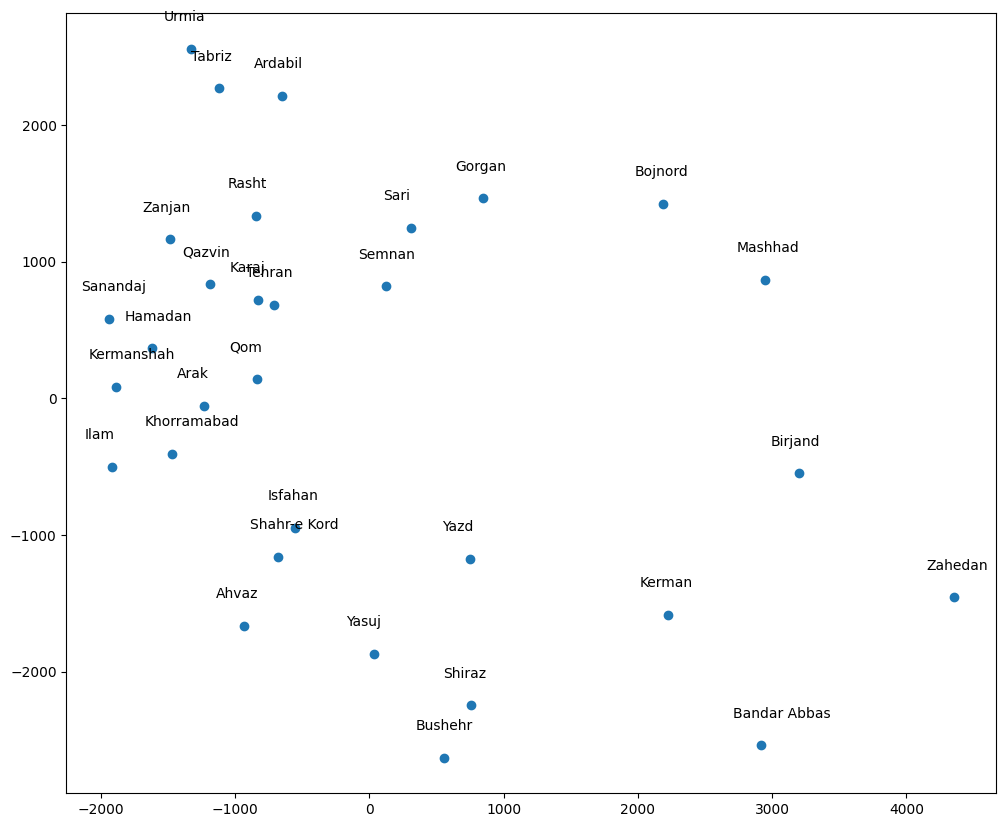

In [20]:
fig = plt.figure(figsize=(12,10))

X = X_transform[:, 0]
y = X_transform[:, 1]

X, y = -y, -X

plt.subplots_adjust(bottom = 0.1)
plt.scatter(X, y)

for label, x, y in zip(df.columns, X, y):
    plt.annotate(
        label,
        xy = (x, y),
        xytext = (-20, 20),
        textcoords = 'offset points'
    )

plt.show()